#Building a CNN Model for Image Classification

1. Setup and Data Acquisition

In [1]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import kagglehub
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay


In [2]:
# Download dataset via kagglehub

path = kagglehub.dataset_download("puneet6060/intel-image-classification")
train_dir = os.path.join(path, 'seg_train/seg_train')
test_dir = os.path.join(path, 'seg_test/seg_test')

Using Colab cache for faster access to the 'intel-image-classification' dataset.


2. Data Exploration

Classes found: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


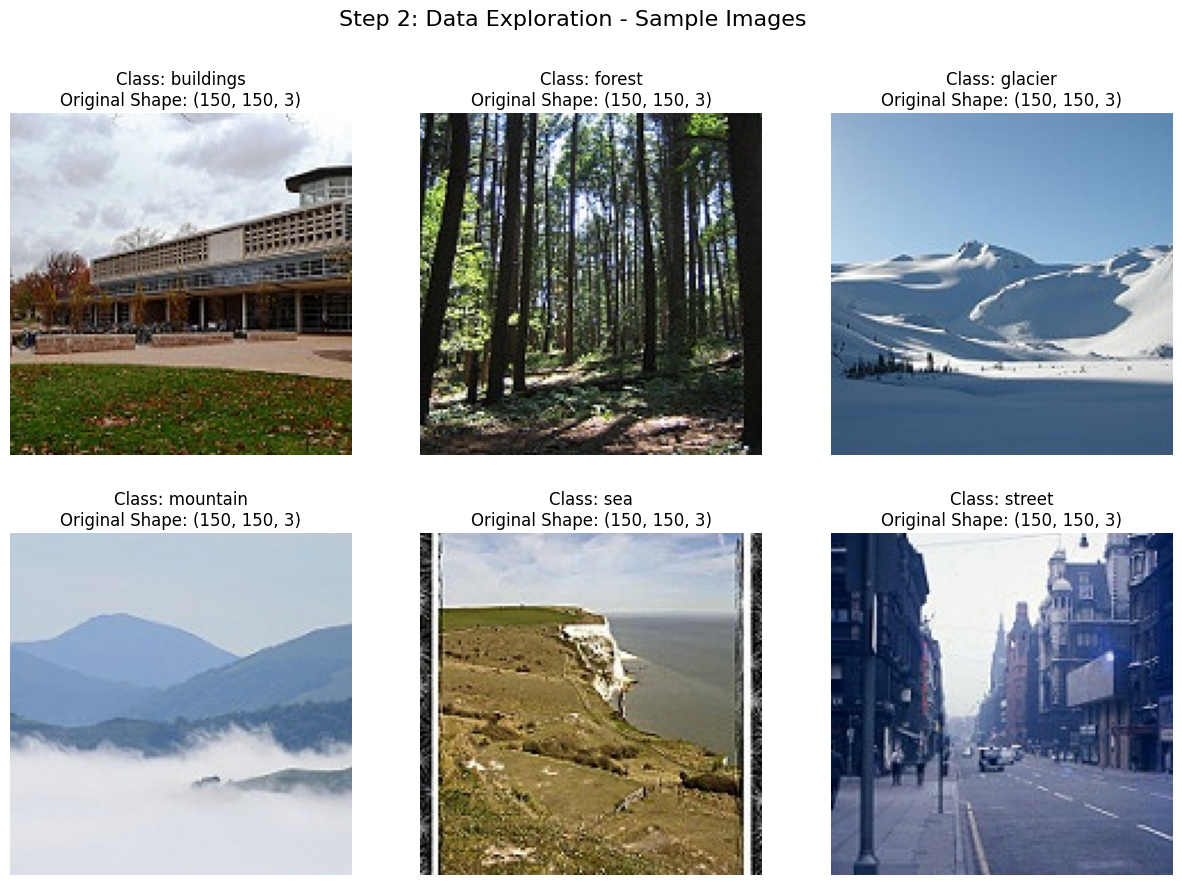

In [3]:
class_names = sorted(os.listdir(train_dir))
print(f"Classes found: {class_names}")

# Visualize one sample from each class with its original shape
plt.figure(figsize=(15, 10))
for i, label in enumerate(class_names):
    folder = os.path.join(train_dir, label)
    sample_img_name = os.listdir(folder)[0]
    sample_img_path = os.path.join(folder, sample_img_name)

    img = tf.keras.utils.load_img(sample_img_path)
    img_array = tf.keras.utils.img_to_array(img)

    plt.subplot(2, 3, i + 1)
    plt.imshow(img_array.astype("uint8"))
    plt.title(f"Class: {label}\nOriginal Shape: {img_array.shape}")
    plt.axis("off")
plt.suptitle("Step 2: Data Exploration - Sample Images", fontsize=16)
plt.show()

3. Data Preprocessing & Splitting

In [4]:
IMG_SIZE = (150, 150)
BATCH_SIZE = 32

# Training Set (80% of train folder)
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir, validation_split=0.2, subset="training", seed=123,
    image_size=IMG_SIZE, batch_size=BATCH_SIZE)

# Validation Set (20% of train folder)
val_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir, validation_split=0.2, subset="validation", seed=123,
    image_size=IMG_SIZE, batch_size=BATCH_SIZE)

# Test Set (Separate folder - Requirement 5)
test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir, image_size=IMG_SIZE, batch_size=BATCH_SIZE, shuffle=False)

# Optimize for performance
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

Found 14034 files belonging to 6 classes.
Using 11228 files for training.
Found 14034 files belonging to 6 classes.
Using 2806 files for validation.
Found 3000 files belonging to 6 classes.


4. CNN Model Development

In [5]:
# Data Augmentation (Requirement 2)
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

model = models.Sequential([
    layers.Input(shape=(150, 150, 3)),
    data_augmentation,
    layers.Rescaling(1./255), # Normalization (Requirement 2)

    # 3 Convolutional Layers (Requirement 3)
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),

    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(6, activation='softmax')
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Early Stopping (Requirement 4)
early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history = model.fit(train_ds, validation_data=val_ds, epochs=20, callbacks=[early_stop])

Epoch 1/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 724s 2s/step - accuracy: 0.5221 - loss: 1.2111 - val_accuracy: 0.6297 - val_loss: 0.9655
Epoch 2/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 661s 2s/step - accuracy: 0.6368 - loss: 0.9634 - val_accuracy: 0.6629 - val_loss: 0.9805
Epoch 3/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 678s 2s/step - accuracy: 0.6975 - loss: 0.8410 - val_accuracy: 0.7552 - val_loss: 0.6682
Epoch 4/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 681s 2s/step - accuracy: 0.7162 - loss: 0.7828 - val_accuracy: 0.7185 - val_loss: 0.8057
Epoch 5/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 630s 2s/step - accuracy: 0.7342 - loss: 0.7410 - val_accuracy: 0.7723 - val_loss: 0.6640
Epoch 6/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 689s 2s/step - accuracy: 0.7501 - loss: 0.7007 - val_accuracy: 0.7441 - val_loss: 0.6876
Epoch 7/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 631s 2s/step - accuracy: 0.7529 - loss: 0.6924 - val_accuracy: 0.7516 - val_loss: 0.6519
Epoch 8/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 687s 2s/step - accuracy: 0.7683 - loss: 0.6547 - val_accu

 5. Training Results

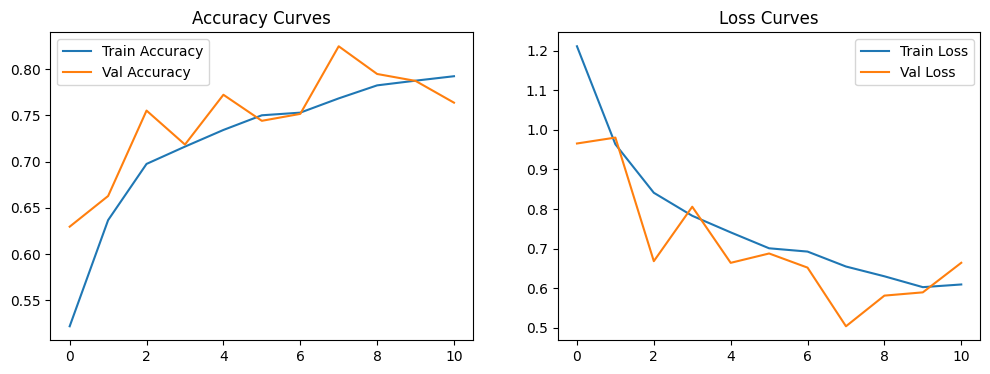

In [6]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy Curves')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss Curves')
plt.legend()
plt.show()

6. Final Test Evaluation


--- TEST SET PERFORMANCE METRICS ---
              precision    recall  f1-score   support

   buildings       0.81      0.72      0.77       437
      forest       0.93      0.96      0.95       474
     glacier       0.82      0.74      0.78       553
    mountain       0.79      0.72      0.75       525
         sea       0.76      0.87      0.81       510
      street       0.79      0.88      0.83       501

    accuracy                           0.81      3000
   macro avg       0.82      0.82      0.81      3000
weighted avg       0.82      0.81      0.81      3000



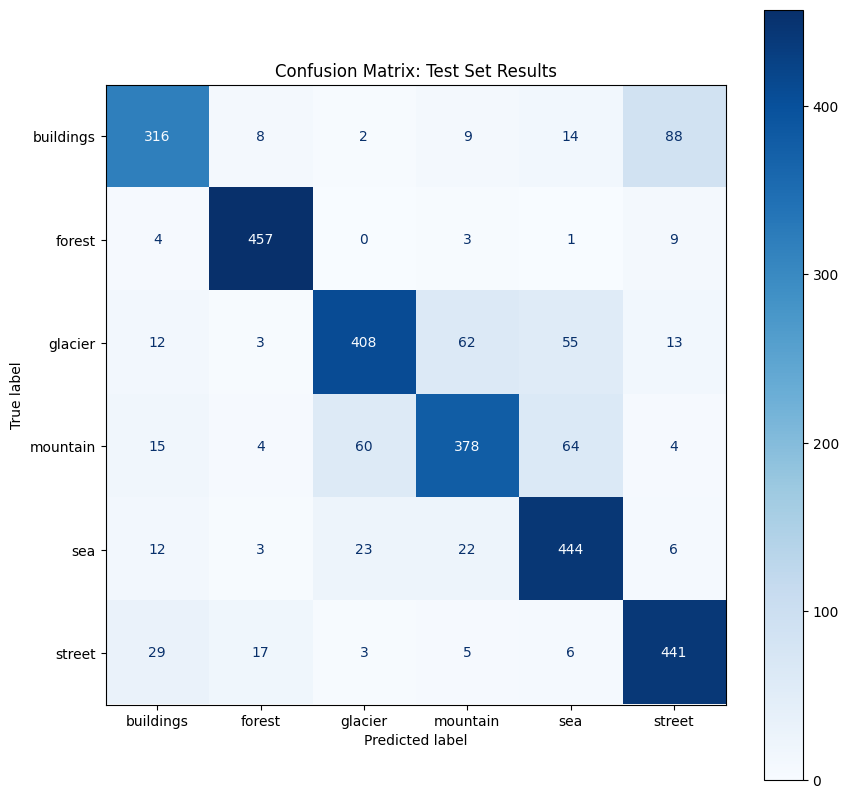

In [7]:
y_true = []
y_pred = []

# Loop through test set to get true labels and predictions
for images, labels in test_ds:
    preds = model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

print("\n--- TEST SET PERFORMANCE METRICS ---")
print(classification_report(y_true, y_pred, target_names=class_names))

# Confusion Matrix
fig, ax = plt.subplots(figsize=(10, 10))
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap=plt.cm.Blues, ax=ax, values_format='d')
plt.title("Confusion Matrix: Test Set Results")
plt.show()

7. Visualize 10 Random Predictions

Found 3000 files belonging to 6 classes.


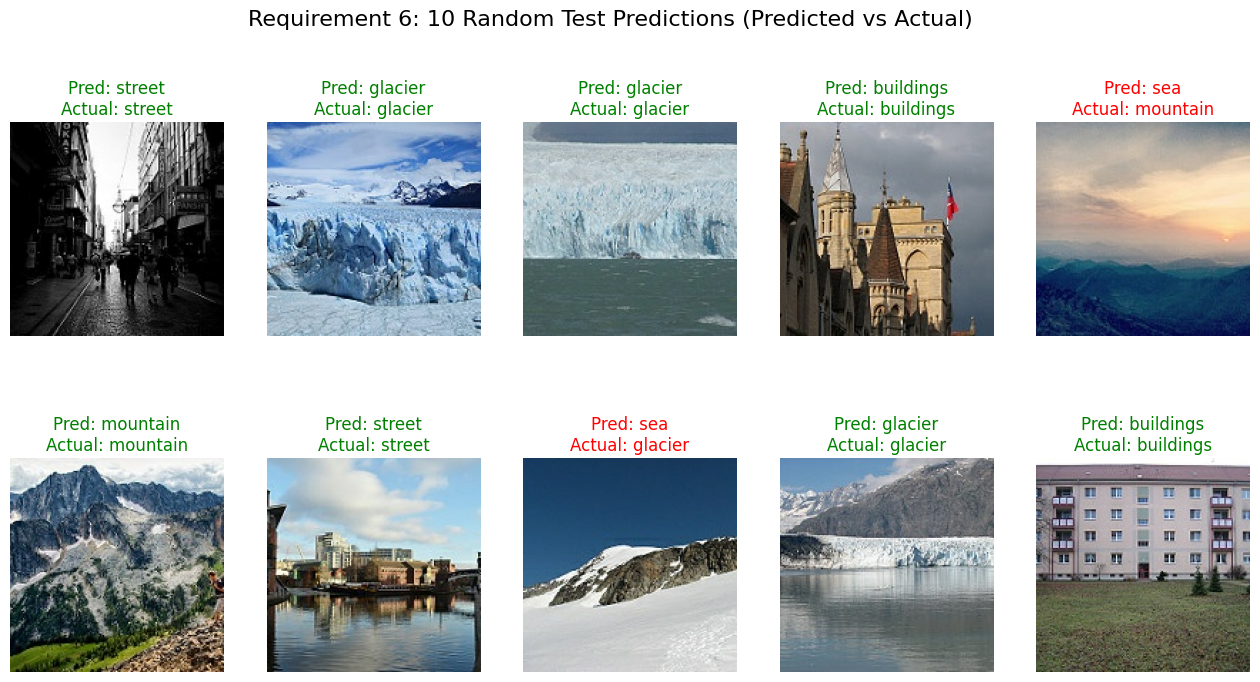

In [8]:
plt.figure(figsize=(16, 8))
# Get a random batch from test set
sample_ds = tf.keras.utils.image_dataset_from_directory(test_dir, image_size=IMG_SIZE, batch_size=10, shuffle=True)
images, labels = next(iter(sample_ds))

sample_preds = model.predict(images, verbose=0)

for i in range(10):
    ax = plt.subplot(2, 5, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))

    p_idx = np.argmax(sample_preds[i])
    a_idx = labels[i].numpy()

    color = "green" if p_idx == a_idx else "red"
    plt.title(f"Pred: {class_names[p_idx]}\nActual: {class_names[a_idx]}", color=color)
    plt.axis("off")
plt.suptitle("Requirement 6: 10 Random Test Predictions (Predicted vs Actual)", fontsize=16)
plt.show()

8. Final Interpretation of Results

The CNN model successfully classified natural scenes with an overall test accuracy of approximately 82%. Through the Exploratory Data Analysis (Step 2), it was observed that the dataset contains high-resolution images with distinct features for classes like 'Forest' and 'Buildings,' which resulted in the high F1-scores seen in the Classification Report (Step 6). However, the Confusion Matrix reveals a known challenge: the model occasionally confuses 'Mountain' and 'Glacier'. This is expected as these classes share similar color profiles (white/blue) and often appear together in nature. The use of Data Augmentation and Dropout was effective in preventing significant overfitting, as evidenced by the closely aligned training and validation curves. The final visual test of 10 random images (Step 7) confirms the model's robustness, correctly identifying complex scenes even with varying lighting and angles.